# MRI Analysis for Fear

## Aniha Chalke 19/12/2025

https://neurosynth.org/analyses/terms/fear/

## Conda Environment

Set up a miniconda environment using the following:

 ```conda create --name mri_analysis python=3.12.4 ```
 
 ```conda activate mri_analysis ```

Once the conda environment is set up, we need to install the required packages using:

 ```pip install -r requirements.txt ```

Now, choose the same kernel for this notebook and run the code below. 


## Importing the packages I need 

In [22]:
from nilearn.image import threshold_img
from nilearn.plotting import find_xyz_cut_coords, plot_stat_map
import nibabel as nib
import matplotlib.pyplot as plt
import os
from pathlib import Path


### Finding the data files in our folder

In [23]:
root = Path('.')
files = os.listdir(root)        # All files in our directory

nii_files = []
for file in files:
    if file.endswith('.nii.gz'):
        nii_files.append(root / file)       # Adding our data files to a list

if len(nii_files) == 0:
    print("No data files found in the current directory.")
    
for filename in nii_files:
    print(filename)

fear_uniformity-test_z_FDR_0.01.nii.gz
anatomical.nii.gz


## Checking for the anatomical and functional files

In [24]:
for filename in nii_files:
    if 'anatomical' in str(filename):
        anatomical_file = filename
    else:
        functional_file = filename

if not anatomical_file or not functional_file:
    print("Couldn't find both required files.")
        

## Visualizing our functional data on top of the anatomical scan

### nilearn allows us to find the optimal x,y,z co-ordinates corresponding to the center of mass of the data

In [25]:
threshold_image = threshold_img(functional_file, threshold=0.1)     # Filtering out any noise
cut_coords = find_xyz_cut_coords(threshold_image)                   # Finding center of mass coordinates
print(cut_coords)

/var/folders/sd/cnxthn7d0cl14d8dtvq31knm0000gn/T/ipykernel_33761/187853554.py:1: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  threshold_image = threshold_img(functional_file, threshold=0.1)     # Filtering out any noise


[24.28209726696626, -2.5000329234998873, -17.61797326186823]


### Now, we can plot our functional data using the co-ordinates we just obtained

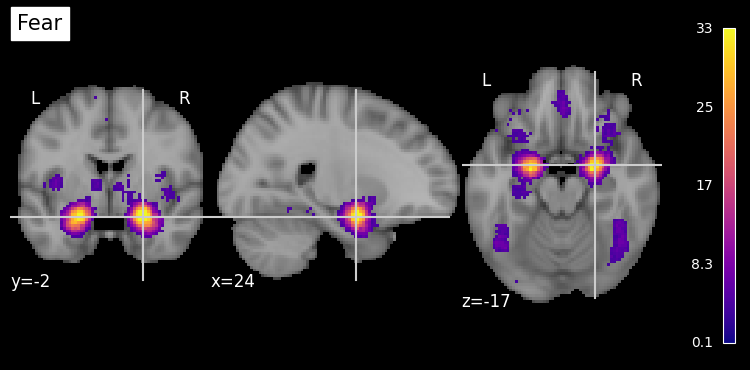

<Figure size 640x480 with 0 Axes>

In [26]:
# Visualizing the data on top of the anatomical image
plot_stat_map(functional_file, bg_img = anatomical_file, title='Fear', cmap='plasma', threshold=0.1, cut_coords=cut_coords, colorbar=True)
plt.show()
plt.savefig('fear_analysis.png')

## Plotting our Histogram

### Loading the file 

In [27]:
anatomical_img = nib.load(anatomical_file)          #Loading our images
functional_img = nib.load(functional_file)      

functional_data = functional_img.get_fdata()        #Extracting the data from our images
functional_data

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

### Filtering for Positive Values 

In [28]:
functional_data = functional_data[functional_data > 0]      #Filtering out negative and 0 values
functional_data

array([3.6550721 , 3.6550721 , 4.56151861, ..., 4.10829535, 3.6550721 ,
       3.6550721 ], shape=(12410,))

### Histogram plotting

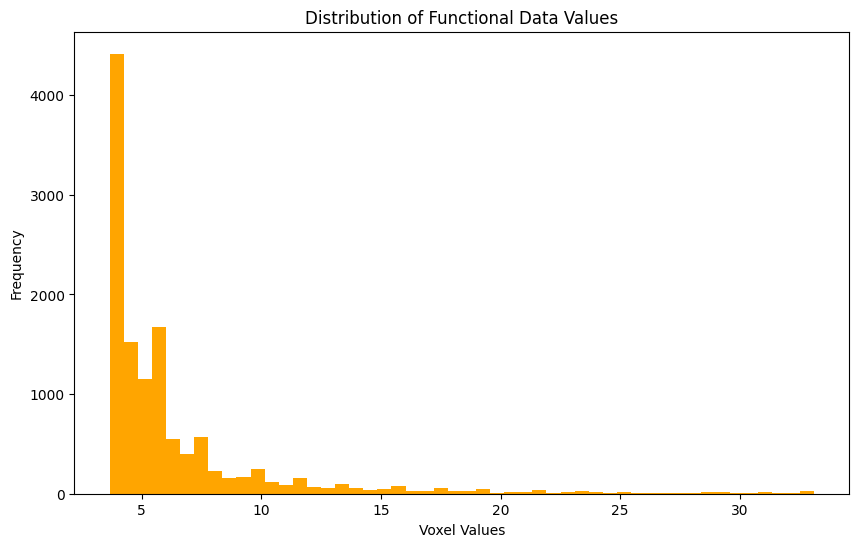

<Figure size 640x480 with 0 Axes>

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))        #Creating histogram
ax.hist(functional_data, bins=50, color='orange')      
#Customizations
ax.set_xlabel('Voxel Values')
ax.set_ylabel('Frequency')
ax.set_title("Distribution of Functional Data Values")
plt.show()
plt.savefig('fear_histogram.png')   